# DATA EXPLORATION

Notebook này thực hiện `Exploratory Data Analysis – EDA` trên European Soccer Database, tập trung vào các bảng `Country`, `League`, `Match`, `Team` và `Team_Attributes`. Notebook chỉ khảo sát dữ liệu, không thực hiện preprocessing, data cleaning, feature engineering chính thức hoặc tạo analytical tables.


## 1. Kết nối và tải dữ liệu phục vụ EDA

Mục này thiết lập môi trường phân tích, kết nối SQLite ở chế độ `read-only` và chỉ tải các bảng/cột cần thiết cho EDA. Với bảng `Match`, notebook chỉ đọc các cột chính thay vì dùng `SELECT *`.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-codex")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import (
    calculate_iqr_bounds,
    connect_sqlite_readonly,
    summarize_duplicate_key,
    summarize_missing_values,
)
from src.viz import (
    plot_average_goals_by_season,
    plot_goal_boxplot,
    plot_goal_histogram,
    plot_match_result_distribution,
    plot_matches_by_league,
    plot_matches_by_season,
    plot_team_attribute_distribution,
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)

DATABASE_PATH = (PROJECT_ROOT / "data" / "raw" / "database.sqlite").resolve()
connection = connect_sqlite_readonly(DATABASE_PATH)

MATCH_COLUMNS = [
    "id", "match_api_id", "country_id", "league_id", "season", "stage", "date",
    "home_team_api_id", "away_team_api_id", "home_team_goal", "away_team_goal",
]
TEAM_ATTRIBUTE_COLUMNS = [
    "id", "team_api_id", "date", "buildUpPlaySpeed", "buildUpPlayPassing",
    "chanceCreationPassing", "chanceCreationCrossing", "chanceCreationShooting",
    "defencePressure", "defenceAggression", "defenceTeamWidth",
]
ATTRIBUTE_COLUMNS = TEAM_ATTRIBUTE_COLUMNS[3:]

country = pd.read_sql_query("SELECT id, name FROM Country;", connection)
league = pd.read_sql_query("SELECT id, country_id, name FROM League;", connection)
team = pd.read_sql_query("SELECT team_api_id, team_long_name, team_short_name FROM Team;", connection)
match = pd.read_sql_query(f"SELECT {', '.join(MATCH_COLUMNS)} FROM Match;", connection)
team_attributes = pd.read_sql_query(f"SELECT {', '.join(TEAM_ATTRIBUTE_COLUMNS)} FROM Team_Attributes;", connection)

print(f"Database path: {DATABASE_PATH}")
print("SQLite connection mode: read-only")


Database path: /home/phat/AI_Project/european-soccer-dashboard/data/raw/database.sqlite
SQLite connection mode: read-only


In [2]:
dataframes = {
    "Country": country,
    "League": league,
    "Match": match,
    "Team": team,
    "Team_Attributes": team_attributes,
}

shape_summary = pd.DataFrame([
    {"table_name": table_name, "row_count": df.shape[0], "column_count": df.shape[1]}
    for table_name, df in dataframes.items()
])

display(shape_summary)
print("Match preview:")
display(match.head())
print("\nTeam_Attributes preview:")
display(team_attributes.head())


,table_name,row_count,column_count
0,Country,11,2
1,League,11,3
2,Match,25979,11
3,Team,299,3
4,Team_Attributes,1458,11


Match preview:


,id,match_api_id,country_id,league_id,season,stage,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,1,492473,1,1,2008/2009,1,2008-08-17 00:00:00,9987,9993,1,1
1,2,492474,1,1,2008/2009,1,2008-08-16 00:00:00,10000,9994,0,0
2,3,492475,1,1,2008/2009,1,2008-08-16 00:00:00,9984,8635,0,3
3,4,492476,1,1,2008/2009,1,2008-08-17 00:00:00,9991,9998,5,0
4,5,492477,1,1,2008/2009,1,2008-08-16 00:00:00,7947,9985,1,3



Team_Attributes preview:


,id,team_api_id,date,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,1,9930,2010-02-22 00:00:00,60,50,60,65,55,50,55,45
1,2,9930,2014-09-19 00:00:00,52,56,54,63,64,47,44,54
2,3,9930,2015-09-10 00:00:00,47,54,54,63,64,47,44,54
3,4,8485,2010-02-22 00:00:00,70,70,70,70,70,60,70,70
4,5,8485,2011-02-22 00:00:00,47,52,53,48,52,47,47,52


**Nhận xét**

Notebook đã tải đúng 5 bảng trong phạm vi phân tích chính, gồm 25.979 trận đấu, 299 đội, 11 giải đấu và 11 quốc gia. Output ban đầu chỉ giữ shape summary và preview của `Match`, `Team_Attributes` để minh họa event table và historical snapshot table. Các bảng cầu thủ không được tải vì chưa thuộc phạm vi EDA chính.


## 2. Kiểm tra phạm vi dữ liệu

Mục này xác nhận phạm vi thời gian, quốc gia, giải đấu và đội bóng thực tế. Các biến ngày chỉ được parse tạm thời để kiểm tra coverage, không ghi đè lên cột gốc.


### 2.1. Temporal coverage

Kiểm tra khoảng ngày của `Match`, danh sách mùa giải, số trận theo mùa và khoảng ngày của `Team_Attributes`.


,table_name,date_min,date_max,unparseable_date_count,season_count
0,Match,2008-07-18,2016-05-25,0,8.0
1,Team_Attributes,2010-02-22,2015-09-10,0,NaN


,season,match_count
0,2008/2009,3326
1,2009/2010,3230
2,2010/2011,3260
3,2011/2012,3220
4,2012/2013,3260
5,2013/2014,3032
6,2014/2015,3325
7,2015/2016,3326


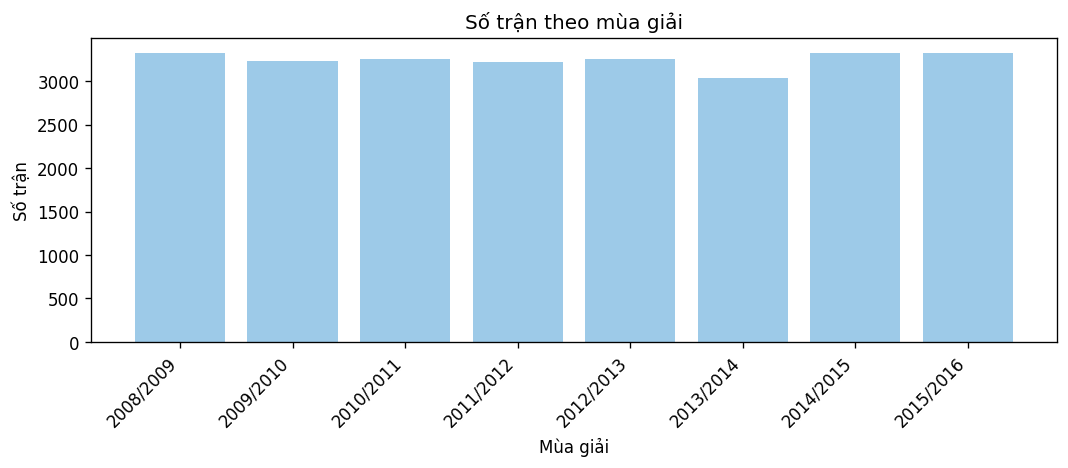

In [3]:
match_dates = pd.to_datetime(match["date"], errors="coerce")
team_attribute_dates = pd.to_datetime(team_attributes["date"], errors="coerce")
season_counts = match.groupby("season", as_index=False).agg(match_count=("id", "count")).sort_values("season")

temporal_summary = pd.DataFrame([
    {"table_name": "Match", "date_min": match_dates.min(), "date_max": match_dates.max(), "unparseable_date_count": match_dates.isna().sum(), "season_count": match["season"].nunique()},
    {"table_name": "Team_Attributes", "date_min": team_attribute_dates.min(), "date_max": team_attribute_dates.max(), "unparseable_date_count": team_attribute_dates.isna().sum(), "season_count": np.nan},
])

display(temporal_summary)
display(season_counts)

plot_matches_by_season(season_counts)
plt.show()


**Nhận xét**

`Match.date` parse được đầy đủ và bao phủ giai đoạn 2008-07-18 đến 2016-05-25, tương ứng 8 mùa từ `2008/2009` đến `2015/2016`. Ngược lại, `Team_Attributes` chỉ có ngày ghi nhận từ 2010-02-22 đến 2015-09-10, ngắn hơn phạm vi lịch sử trận đấu. Điều này là giới hạn quan trọng cho Q4 và Q5 vì thuộc tính đội không bao phủ đầy đủ toàn bộ giai đoạn thi đấu và cần xử lý `temporal alignment` ở preprocessing.


### 2.2. Geographical and league coverage

Kiểm tra danh sách quốc gia, giải đấu, số trận theo quốc gia/giải đấu và số mùa được bao phủ bởi từng giải.


In [4]:
match_enriched = (
    match.merge(
        league[["id", "name"]].rename(columns={"id": "league_id", "name": "league_name"}),
        on="league_id",
        how="left",
    )
    .merge(
        country.rename(columns={"id": "country_id", "name": "country_name"}),
        on="country_id",
        how="left",
    )
)

country_coverage = (
    match_enriched.groupby("country_name", as_index=False)
    .agg(match_count=("id", "count"), season_count=("season", "nunique"))
    .sort_values("match_count", ascending=False)
)
league_coverage = (
    match_enriched.groupby("league_name", as_index=False)
    .agg(match_count=("id", "count"), season_count=("season", "nunique"))
    .sort_values("match_count", ascending=False)
)
league_country = (
    league.merge(country, left_on="country_id", right_on="id", suffixes=("_league", "_country"))
    [["name_country", "name_league"]]
    .rename(columns={"name_country": "country_name", "name_league": "league_name"})
    .sort_values("country_name")
)

print("Danh sách quốc gia:")
display(country.sort_values("name"))
print("\nDanh sách giải đấu:")
display(league_country)


Danh sách quốc gia:


,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy
5,13274,Netherlands
6,15722,Poland
7,17642,Portugal
8,19694,Scotland
9,21518,Spain



Danh sách giải đấu:


,country_name,league_name
0,Belgium,Belgium Jupiler League
1,England,England Premier League
2,France,France Ligue 1
3,Germany,Germany 1. Bundesliga
4,Italy,Italy Serie A
5,Netherlands,Netherlands Eredivisie
6,Poland,Poland Ekstraklasa
7,Portugal,Portugal Liga ZON Sagres
8,Scotland,Scotland Premier League
9,Spain,Spain LIGA BBVA


In [5]:
print("Coverage theo quốc gia:")
display(country_coverage)
print("\nCoverage theo giải đấu:")
display(league_coverage)


Coverage theo quốc gia:


,country_name,match_count,season_count
1,England,3040,8
2,France,3040,8
9,Spain,3040,8
4,Italy,3017,8
5,Netherlands,2448,8
3,Germany,2448,8
7,Portugal,2052,8
6,Poland,1920,8
8,Scotland,1824,8
0,Belgium,1728,8



Coverage theo giải đấu:


,league_name,match_count,season_count
1,England Premier League,3040,8
2,France Ligue 1,3040,8
9,Spain LIGA BBVA,3040,8
4,Italy Serie A,3017,8
5,Netherlands Eredivisie,2448,8
3,Germany 1. Bundesliga,2448,8
7,Portugal Liga ZON Sagres,2052,8
6,Poland Ekstraklasa,1920,8
8,Scotland Premier League,1824,8
0,Belgium Jupiler League,1728,8


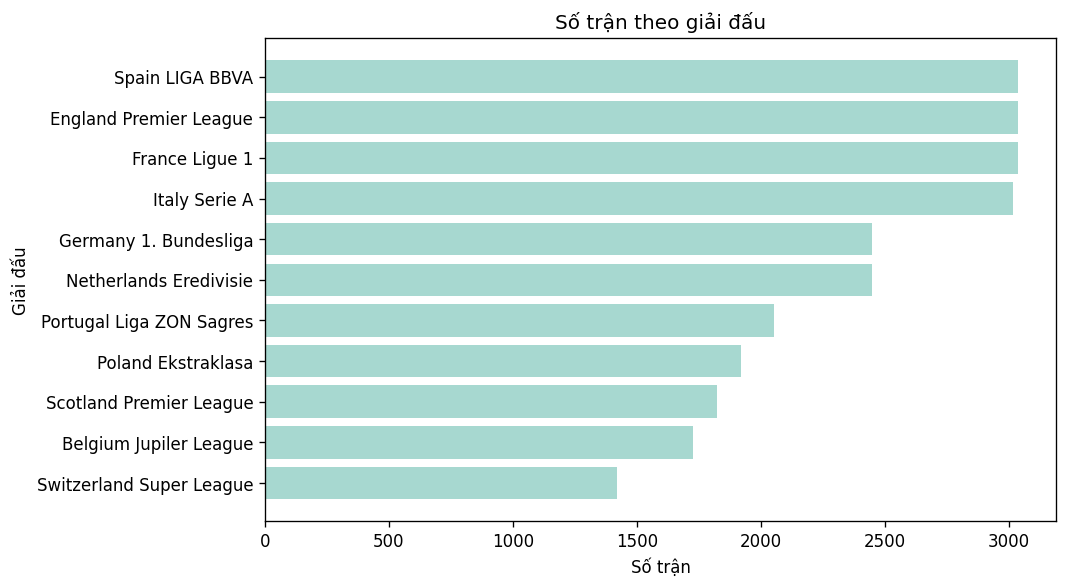

In [6]:
plot_matches_by_league(league_coverage)
plt.show()


**Nhận xét**

Dữ liệu bao phủ 11 quốc gia và 11 giải đấu, mỗi quốc gia tương ứng một league trong dataset hiện tại. Mỗi league đều có 8 mùa, nhưng số trận khác nhau rõ rệt: các giải lớn như England, France và Spain có 3.040 trận, trong khi Switzerland có 1.422 trận. Vì vậy, khi phân tích Q1 cần so sánh theo league-season và có chuẩn hóa theo số đội hoặc số trận, không chỉ dùng tổng số trận tuyệt đối.


### 2.3. Team coverage

Kiểm tra số đội duy nhất, vai trò Home/Away và mức độ bao phủ giữa `Team` và `Match`.


In [7]:
home_team_ids = set(match["home_team_api_id"].dropna())
away_team_ids = set(match["away_team_api_id"].dropna())
match_team_ids = home_team_ids | away_team_ids
team_ids = set(team["team_api_id"].dropna())

team_coverage_summary = pd.DataFrame([
    {"metric": "Số đội trong bảng Team", "value": len(team_ids)},
    {"metric": "Số đội xuất hiện trong Match", "value": len(match_team_ids)},
    {"metric": "Số đội xuất hiện vai trò Home", "value": len(home_team_ids)},
    {"metric": "Số đội xuất hiện vai trò Away", "value": len(away_team_ids)},
    {"metric": "Số đội trong Match nhưng không có trong Team", "value": len(match_team_ids - team_ids)},
    {"metric": "Số đội trong Team nhưng không xuất hiện trong Match", "value": len(team_ids - match_team_ids)},
    {"metric": "Số đội chỉ xuất hiện Home", "value": len(home_team_ids - away_team_ids)},
    {"metric": "Số đội chỉ xuất hiện Away", "value": len(away_team_ids - home_team_ids)},
])

league_season_team_counts = []
for (league_name, season), group in match_enriched.groupby(["league_name", "season"]):
    teams_in_group = pd.concat([group["home_team_api_id"], group["away_team_api_id"]], ignore_index=True).dropna()
    league_season_team_counts.append({"league_name": league_name, "season": season, "team_count": teams_in_group.nunique(), "match_count": len(group)})
league_season_team_counts = pd.DataFrame(league_season_team_counts)
team_count_summary = league_season_team_counts.groupby("league_name", as_index=False).agg(
    min_team_count=("team_count", "min"), median_team_count=("team_count", "median"), max_team_count=("team_count", "max"),
    min_match_count=("match_count", "min"), max_match_count=("match_count", "max"),
).sort_values("league_name")

display(team_coverage_summary)
print("\nTóm tắt số đội theo league-season:")
display(team_count_summary)
print("\nMột vài league-season có số đội thấp nhất:")
display(league_season_team_counts.sort_values(["team_count", "match_count"]).head(10))


,metric,value
0,Số đội trong bảng Team,299
1,Số đội xuất hiện trong Match,299
2,Số đội xuất hiện vai trò Home,299
3,Số đội xuất hiện vai trò Away,299
4,Số đội trong Match nhưng không có trong Team,0
5,Số đội trong Team nhưng không xuất hiện trong ...,0
6,Số đội chỉ xuất hiện Home,0
7,Số đội chỉ xuất hiện Away,0



Tóm tắt số đội theo league-season:


,league_name,min_team_count,median_team_count,max_team_count,min_match_count,max_match_count
0,Belgium Jupiler League,4,16.0,18,12,306
1,England Premier League,20,20.0,20,380,380
2,France Ligue 1,20,20.0,20,380,380
3,Germany 1. Bundesliga,18,18.0,18,306,306
4,Italy Serie A,20,20.0,20,358,380
5,Netherlands Eredivisie,18,18.0,18,306,306
6,Poland Ekstraklasa,16,16.0,16,240,240
7,Portugal Liga ZON Sagres,16,16.0,18,240,306
8,Scotland Premier League,12,12.0,12,228,228
9,Spain LIGA BBVA,20,20.0,20,380,380



Một vài league-season có số đội thấp nhất:


,league_name,season,team_count,match_count
5,Belgium Jupiler League,2013/2014,4,12
83,Switzerland Super League,2011/2012,10,162
80,Switzerland Super League,2008/2009,10,180
81,Switzerland Super League,2009/2010,10,180
82,Switzerland Super League,2010/2011,10,180
84,Switzerland Super League,2012/2013,10,180
85,Switzerland Super League,2013/2014,10,180
86,Switzerland Super League,2014/2015,10,180
87,Switzerland Super League,2015/2016,10,180
64,Scotland Premier League,2008/2009,12,228


**Nhận xét**

Coverage giữa `Team` và `Match` là đầy đủ theo `team_api_id`: cả 299 đội trong `Team` đều xuất hiện trong `Match`, không có đội orphan ở chiều ngược lại. Không có đội chỉ xuất hiện với vai trò Home hoặc Away, nên coverage vai trò Home và Away là đầy đủ vì mọi đội đều xuất hiện ở cả hai vai trò. Số đội theo league-season vẫn khác nhau giữa các giải, vì vậy các so sánh theo league cần đặt trong đúng bối cảnh lịch thi đấu.


## 3. Kiểm tra chất lượng dữ liệu cơ bản

Mục này kiểm tra `missing values`, `duplicate`, datatype và các vi phạm `business rule` cơ bản. Notebook chỉ báo cáo vấn đề, không xử lý hay chỉnh sửa dữ liệu nguồn.


### 3.1. Missing values

Tính số lượng và tỷ lệ missing cho các cột quan trọng trong từng bảng thuộc phạm vi chính.


In [8]:
important_columns = {
    "Country": ["id", "name"],
    "League": ["id", "country_id", "name"],
    "Match": ["league_id", "season", "date", "home_team_api_id", "away_team_api_id", "home_team_goal", "away_team_goal"],
    "Team": ["team_api_id", "team_long_name", "team_short_name"],
    "Team_Attributes": ["team_api_id", "date", *ATTRIBUTE_COLUMNS],
}

missing_reports = []
for table_name, df in dataframes.items():
    report = summarize_missing_values(
        df,
        columns=important_columns[table_name],
        table_name=table_name,
    )
    missing_reports.append(report)
missing_detail = pd.concat(missing_reports, ignore_index=True)
missing_summary = (
    missing_detail.groupby("table_name", as_index=False)
    .agg(
        checked_column_count=("column_name", "count"),
        columns_with_missing=("missing_count", lambda values: int((values > 0).sum())),
        total_missing=("missing_count", "sum"),
    )
)

display(missing_summary)
missing_columns = missing_detail.loc[missing_detail["missing_count"] > 0]
if not missing_columns.empty:
    display(missing_columns)


,table_name,checked_column_count,columns_with_missing,total_missing
0,Country,2,0,0
1,League,3,0,0
2,Match,7,0,0
3,Team,3,0,0
4,Team_Attributes,10,0,0


**Nhận xét**

Missing summary cho thấy các cột quan trọng được kiểm tra đều có `columns_with_missing = 0` và `total_missing = 0`. Điều này bao gồm các cột trận đấu chính và nhóm thuộc tính chiến thuật được chọn trong `Team_Attributes`. Notebook chỉ báo cáo missing values, không điền hoặc loại bỏ dữ liệu.


### 3.2. Duplicate

Kiểm tra duplicate toàn dòng, duplicate primary key và các business key quan trọng như `match_api_id`, `team_api_id`, `team_api_id + date`.


In [9]:
def full_row_duplicate_count(dataframe: pd.DataFrame) -> int:
    return int(dataframe.duplicated(keep=False).sum())


duplicate_checks = [
    {"table_name": "Country", "check": "Full row duplicate", "duplicate_rows": full_row_duplicate_count(country), "duplicate_groups": 0},
    {"table_name": "League", "check": "Full row duplicate", "duplicate_rows": full_row_duplicate_count(league), "duplicate_groups": 0},
    {"table_name": "Match", "check": "Full row duplicate", "duplicate_rows": full_row_duplicate_count(match), "duplicate_groups": 0},
    {"table_name": "Team", "check": "Full row duplicate", "duplicate_rows": full_row_duplicate_count(team), "duplicate_groups": 0},
    {"table_name": "Team_Attributes", "check": "Full row duplicate", "duplicate_rows": full_row_duplicate_count(team_attributes), "duplicate_groups": 0},
]
for table_name, df, key_columns in [
    ("Match", match, ["id"]),
    ("Match", match, ["match_api_id"]),
    ("Team", team, ["team_api_id"]),
    ("Team_Attributes", team_attributes, ["team_api_id", "date"]),
]:
    duplicate_checks.append(
        {
            "table_name": table_name,
            "check": " + ".join(key_columns),
            **summarize_duplicate_key(df, key_columns),
        }
    )

duplicate_report = pd.DataFrame(duplicate_checks)[
    ["table_name", "check", "duplicate_rows", "duplicate_groups"]
]
display(duplicate_report)


,table_name,check,duplicate_rows,duplicate_groups
0,Country,Full row duplicate,0,0
1,League,Full row duplicate,0,0
2,Match,Full row duplicate,0,0
3,Team,Full row duplicate,0,0
4,Team_Attributes,Full row duplicate,0,0
5,Match,id,0,0
6,Match,match_api_id,0,0
7,Team,team_api_id,0,0
8,Team_Attributes,team_api_id + date,2,1


In [10]:
team_attribute_duplicate_examples = team_attributes.loc[team_attributes.duplicated(subset=["team_api_id", "date"], keep=False)].sort_values(["team_api_id", "date"])
print("Ví dụ duplicate business key trong Team_Attributes:")
display(team_attribute_duplicate_examples.head(10))

Ví dụ duplicate business key trong Team_Attributes:


,id,team_api_id,date,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
859,860,9996,2015-09-10 00:00:00,50,50,50,50,50,45,45,50
860,861,9996,2015-09-10 00:00:00,50,50,50,50,50,45,45,50


**Nhận xét**

Không phát hiện `duplicate` toàn dòng trong các bảng đã tải và các key chính như `Match.id`, `Match.match_api_id`, `Team.team_api_id` đều không trùng. Điểm cần lưu ý nằm ở `Team_Attributes`: tổ hợp `team_api_id + date` có 1 nhóm duplicate gồm 2 dòng, dù các giá trị thuộc tính hiển thị giống nhau trong ví dụ. Vì vậy tổ hợp này chưa nên được dùng như business key duy nhất nếu chưa có rule xử lý ở preprocessing.


### 3.3. Data types

Kiểm tra datatype hiện tại, khả năng parse ngày, numeric columns và format của `season`.


In [11]:
type_validation_columns = {
    "Match": ["date", "season", "stage", "home_team_goal", "away_team_goal"],
    "Team_Attributes": ["date", *ATTRIBUTE_COLUMNS],
}

type_validation_records = []
for table_name, df in [("Match", match), ("Team_Attributes", team_attributes)]:
    for column in type_validation_columns[table_name]:
        loaded_dtype = str(df[column].dtype)
        if column == "date":
            parse_failure_count = int(pd.to_datetime(df[column], errors="coerce").isna().sum())
            validation_status = "Date parse OK" if parse_failure_count == 0 else "Date parse issue"
        elif column == "season":
            parse_failure_count = int((~df[column].astype(str).str.match(r"^\d{4}/\d{4}$", na=False)).sum())
            validation_status = "Season format OK" if parse_failure_count == 0 else "Season format issue"
        else:
            numeric_values = pd.to_numeric(df[column], errors="coerce")
            parse_failure_count = int(numeric_values.isna().sum() - df[column].isna().sum())
            validation_status = "Numeric parse OK" if parse_failure_count == 0 else "Numeric parse issue"
        type_validation_records.append(
            {
                "table_name": table_name,
                "column_name": column,
                "loaded_dtype": loaded_dtype,
                "parse_failure_count": parse_failure_count,
                "validation_status": validation_status,
            }
        )

type_validation_summary = pd.DataFrame(type_validation_records)
display(type_validation_summary)


,table_name,column_name,loaded_dtype,parse_failure_count,validation_status
0,Match,date,object,0,Date parse OK
1,Match,season,object,0,Season format OK
2,Match,stage,int64,0,Numeric parse OK
3,Match,home_team_goal,int64,0,Numeric parse OK
4,Match,away_team_goal,int64,0,Numeric parse OK
5,Team_Attributes,date,object,0,Date parse OK
6,Team_Attributes,buildUpPlaySpeed,int64,0,Numeric parse OK
7,Team_Attributes,buildUpPlayPassing,int64,0,Numeric parse OK
8,Team_Attributes,chanceCreationPassing,int64,0,Numeric parse OK
9,Team_Attributes,chanceCreationCrossing,int64,0,Numeric parse OK


**Nhận xét**

`type_validation_summary` tập trung vào các cột cần parse hoặc kiểm tra format: ngày, `season`, `stage`, bàn thắng và các thuộc tính numeric đã chọn. Tất cả cột được kiểm tra đều parse thành công hoặc đúng pattern kỳ vọng. Việc chuẩn hóa datatype chính thức vẫn thuộc preprocessing, không thực hiện trong EDA.


### 3.4. Business-rule validation

Kiểm tra các vi phạm cơ bản về đội thi đấu, bàn thắng, stage, season, ngày và khả năng liên kết đội bóng.


In [12]:
match_date_parsed = pd.to_datetime(match["date"], errors="coerce")
season_pattern_invalid = ~match["season"].astype(str).str.match(r"^\d{4}/\d{4}$", na=False)
team_ids = set(team["team_api_id"].dropna())
home_goal_numeric = pd.to_numeric(match["home_team_goal"], errors="coerce")
away_goal_numeric = pd.to_numeric(match["away_team_goal"], errors="coerce")
goal_upper_threshold = 10

business_rule_report = pd.DataFrame([
    {"check_name": "home_team_api_id == away_team_api_id", "violation_count": int((match["home_team_api_id"] == match["away_team_api_id"]).sum()), "evidence": "Một trận không nên có cùng đội ở hai vai trò"},
    {"check_name": "Negative goals", "violation_count": int(((home_goal_numeric < 0) | (away_goal_numeric < 0)).sum()), "evidence": "Bàn thắng không được âm"},
    {"check_name": "Non-integer goals", "violation_count": int((home_goal_numeric.dropna() % 1 != 0).sum() + (away_goal_numeric.dropna() % 1 != 0).sum()), "evidence": "Bàn thắng nên là số nguyên"},
    {"check_name": "stage <= 0", "violation_count": int((match["stage"] <= 0).sum()), "evidence": "Stage thi đấu nên là số dương"},
    {"check_name": "Invalid season pattern", "violation_count": int(season_pattern_invalid.sum()), "evidence": "Season nên có dạng YYYY/YYYY"},
    {"check_name": "Missing or unparseable date", "violation_count": int(match_date_parsed.isna().sum()), "evidence": "Date cần parse được để phân tích theo thời gian"},
    {"check_name": "Home team not found in Team", "violation_count": int((~match["home_team_api_id"].isin(team_ids)).sum()), "evidence": "home_team_api_id cần tồn tại trong Team.team_api_id"},
    {"check_name": "Away team not found in Team", "violation_count": int((~match["away_team_api_id"].isin(team_ids)).sum()), "evidence": "away_team_api_id cần tồn tại trong Team.team_api_id"},
    {"check_name": f"Goal value >= {goal_upper_threshold}", "violation_count": int(((home_goal_numeric >= goal_upper_threshold) | (away_goal_numeric >= goal_upper_threshold)).sum()), "evidence": f"Max home goals = {home_goal_numeric.max()}, max away goals = {away_goal_numeric.max()}"},
])
display(business_rule_report)


,check_name,violation_count,evidence
0,home_team_api_id == away_team_api_id,0,Một trận không nên có cùng đội ở hai vai trò
1,Negative goals,0,Bàn thắng không được âm
2,Non-integer goals,0,Bàn thắng nên là số nguyên
3,stage <= 0,0,Stage thi đấu nên là số dương
4,Invalid season pattern,0,Season nên có dạng YYYY/YYYY
5,Missing or unparseable date,0,Date cần parse được để phân tích theo thời gian
6,Home team not found in Team,0,home_team_api_id cần tồn tại trong Team.team_a...
7,Away team not found in Team,0,away_team_api_id cần tồn tại trong Team.team_a...
8,Goal value >= 10,2,"Max home goals = 10, max away goals = 9"


**Nhận xét**

Không phát hiện vi phạm `business rule` ở các kiểm tra cơ bản: không có trận cùng đội ở hai vai trò, không có bàn thắng âm, không có stage không hợp lệ, và mọi đội trong `Match` đều tìm thấy trong `Team`. Có 2 trận mà một đội ghi từ 10 bàn trở lên; đây là `Extreme value` cần được kiểm tra bằng ngữ cảnh bóng đá, chưa đủ cơ sở để xem là lỗi. Các kiểm tra có vi phạm bằng 0 không được đưa vào `issue_summary` như một vấn đề dữ liệu.


## 4. Thống kê mô tả và phân bố dữ liệu

Mục này khảo sát phân bố của các biến quan trọng ở cấp trận đấu và thuộc tính đội. Các biến như `total_goals` chỉ là biến tạm thời phục vụ EDA.


### 4.1. Match variables

Tạo `total_goals` tạm thời và khảo sát phân bố bàn thắng đội nhà, đội khách và tổng bàn thắng.


,count,mean,std,min,25%,50%,75%,max
home_team_goal,25979.0,1.544594,1.297158,0.0,1.0,1.0,2.0,10.0
away_team_goal,25979.0,1.160938,1.142110,0.0,0.0,1.0,2.0,9.0
total_goals,25979.0,2.705531,1.672456,0.0,2.0,3.0,4.0,12.0


Quantile:


,q01,q05,q25,q50,q75,q95,q99
home_team_goal,0.0,0.0,1.0,1.0,2.0,4.0,5.0
away_team_goal,0.0,0.0,0.0,1.0,2.0,3.0,5.0
total_goals,0.0,0.0,2.0,3.0,4.0,6.0,7.0


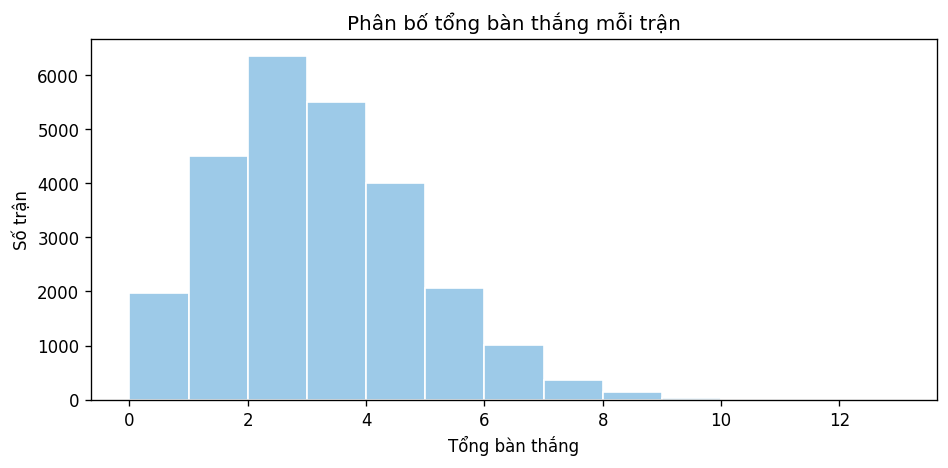

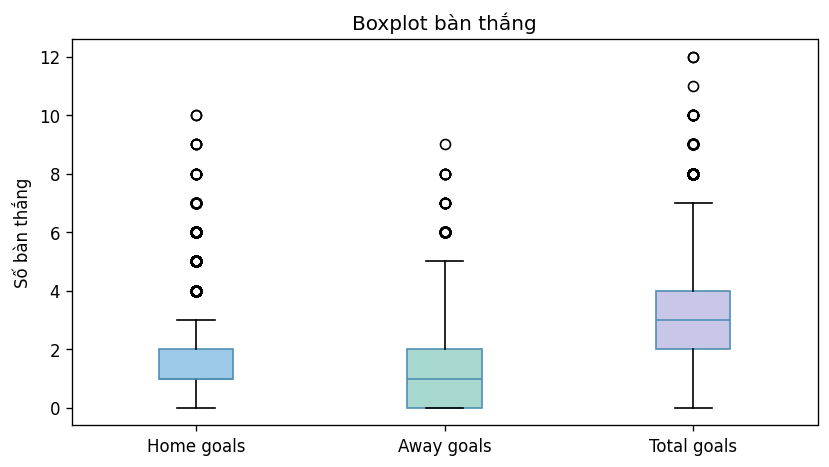

In [13]:
match_metrics = match_enriched.assign(
    total_goals=match_enriched["home_team_goal"] + match_enriched["away_team_goal"],
    goal_diff=match_enriched["home_team_goal"] - match_enriched["away_team_goal"],
)
match_goal_columns = ["home_team_goal", "away_team_goal", "total_goals"]
goal_describe = match_metrics[match_goal_columns].describe().T
quantiles = match_metrics[match_goal_columns].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
quantiles.columns = [f"q{int(q * 100):02d}" for q in quantiles.columns]

display(goal_describe)
print("Quantile:")
display(quantiles)

plot_goal_histogram(match_metrics["total_goals"])
plt.show()

plot_goal_boxplot(
    match_metrics,
    columns=["home_team_goal", "away_team_goal", "total_goals"],
    labels=["Home goals", "Away goals", "Total goals"],
)
plt.show()


**Nhận xét**

Tổng bàn thắng trung bình mỗi trận là 2,71, median là 3 và 99th percentile là 7 bàn. Phân bố lệch phải: phần lớn trận nằm ở vùng 0-4 bàn, nhưng vẫn có một số trận rất cao với tổng bàn thắng tối đa là 12. Các giá trị này nên được ghi nhận là `Extreme value` hoặc `Potential outlier`, nhưng chưa được loại bỏ trong EDA vì vẫn có thể là kết quả hợp lệ.


### 4.2. Categorical variables

Khảo sát số trận theo `season`, `league`, `country` và tần suất `stage` ở mức tổng hợp.


In [14]:
season_distribution = match_enriched["season"].value_counts().sort_index().rename_axis("season").reset_index(name="match_count")
league_distribution = match_enriched["league_name"].value_counts().rename_axis("league_name").reset_index(name="match_count")
country_distribution = match_enriched["country_name"].value_counts().rename_axis("country_name").reset_index(name="match_count")
stage_distribution = match_enriched["stage"].value_counts().sort_index().rename_axis("stage").reset_index(name="match_count")

print("Số trận theo season:")
display(season_distribution)
print("\nSố trận theo league:")
display(league_distribution)


Số trận theo season:


,season,match_count
0,2008/2009,3326
1,2009/2010,3230
2,2010/2011,3260
3,2011/2012,3220
4,2012/2013,3260
5,2013/2014,3032
6,2014/2015,3325
7,2015/2016,3326



Số trận theo league:


,league_name,match_count
0,England Premier League,3040
1,France Ligue 1,3040
2,Spain LIGA BBVA,3040
3,Italy Serie A,3017
4,Netherlands Eredivisie,2448
5,Germany 1. Bundesliga,2448
6,Portugal Liga ZON Sagres,2052
7,Poland Ekstraklasa,1920
8,Scotland Premier League,1824
9,Belgium Jupiler League,1728


In [15]:
print("Số trận theo country:")
display(country_distribution)
print("\nTần suất stage:")
display(stage_distribution.head(15))


Số trận theo country:


,country_name,match_count
0,England,3040
1,France,3040
2,Spain,3040
3,Italy,3017
4,Netherlands,2448
5,Germany,2448
6,Portugal,2052
7,Poland,1920
8,Scotland,1824
9,Belgium,1728



Tần suất stage:


,stage,match_count
0,1,740
1,2,740
2,3,740
3,4,740
4,5,740
5,6,740
6,7,738
7,8,738
8,9,738
9,10,738


**Nhận xét**

Số trận theo mùa dao động từ 3.032 đến 3.326, trong đó mùa `2013/2014` thấp hơn các mùa còn lại. Số trận theo league/country khác nhau chủ yếu do cấu trúc giải và số đội, còn `stage` có tần suất thay đổi ở các stage cao hơn, phù hợp với khả năng các league có số đội hoặc cấu trúc mùa giải khác nhau. Các biến categorical đủ để phân tích theo season và league, nhưng cần kiểm tra coverage bất thường trước khi tính chỉ số cạnh tranh.


### 4.3. Team Attributes

Khảo sát thống kê mô tả, missing rate, số bản ghi theo đội, số ngày ghi nhận và correlation matrix của các thuộc tính chiến thuật được chọn.


In [16]:
attribute_describe = team_attributes[ATTRIBUTE_COLUMNS].describe().T
attribute_missing = pd.DataFrame({
    "column_name": ATTRIBUTE_COLUMNS,
    "missing_count": team_attributes[ATTRIBUTE_COLUMNS].isna().sum().values,
    "missing_rate_pct": (team_attributes[ATTRIBUTE_COLUMNS].isna().mean().values * 100).round(2),
})

print("Thống kê mô tả thuộc tính đội:")
display(attribute_describe)
print("\nMissing rate của thuộc tính đội:")
display(attribute_missing)


Thống kê mô tả thuộc tính đội:


,count,mean,std,min,25%,50%,75%,max
buildUpPlaySpeed,1458.0,52.462277,11.545869,20.0,45.0,52.0,62.0,80.0
buildUpPlayPassing,1458.0,48.490398,10.896101,20.0,40.0,50.0,55.0,80.0
chanceCreationPassing,1458.0,52.165295,10.360793,21.0,46.0,52.0,59.0,80.0
chanceCreationCrossing,1458.0,53.731824,11.086796,20.0,47.0,53.0,62.0,80.0
chanceCreationShooting,1458.0,53.969136,10.327566,22.0,48.0,53.0,61.0,80.0
defencePressure,1458.0,46.017147,10.227225,23.0,39.0,45.0,51.0,72.0
defenceAggression,1458.0,49.251029,9.738028,24.0,44.0,48.0,55.0,72.0
defenceTeamWidth,1458.0,52.185871,9.574712,29.0,47.0,52.0,58.0,73.0



Missing rate của thuộc tính đội:


,column_name,missing_count,missing_rate_pct
0,buildUpPlaySpeed,0,0.0
1,buildUpPlayPassing,0,0.0
2,chanceCreationPassing,0,0.0
3,chanceCreationCrossing,0,0.0
4,chanceCreationShooting,0,0.0
5,defencePressure,0,0.0
6,defenceAggression,0,0.0
7,defenceTeamWidth,0,0.0


In [17]:
attribute_quantiles = team_attributes[ATTRIBUTE_COLUMNS].quantile([0.01, 0.25, 0.5, 0.75, 0.99]).T
attribute_quantiles.columns = ["q01", "q25", "q50", "q75", "q99"]

print("Quantile của thuộc tính đội:")
display(attribute_quantiles)


Quantile của thuộc tính đội:


,q01,q25,q50,q75,q99
buildUpPlaySpeed,29.00,45.0,52.0,62.0,74.43
buildUpPlayPassing,27.57,40.0,50.0,55.0,72.00
chanceCreationPassing,30.00,46.0,52.0,59.0,72.00
chanceCreationCrossing,30.00,47.0,53.0,62.0,75.43
chanceCreationShooting,30.00,48.0,53.0,61.0,73.43
defencePressure,25.00,39.0,45.0,51.0,70.00
defenceAggression,30.00,44.0,48.0,55.0,70.00
defenceTeamWidth,30.00,47.0,52.0,58.0,70.00


In [18]:
attribute_records_per_team = team_attributes.groupby("team_api_id").size().reset_index(name="record_count")
attribute_dates_per_team = team_attributes.groupby("team_api_id")["date"].nunique().reset_index(name="distinct_date_count")

print("Số bản ghi thuộc tính theo đội:")
display(attribute_records_per_team["record_count"].describe().to_frame().T)
print("\nSố ngày ghi nhận thuộc tính theo đội:")
display(attribute_dates_per_team["distinct_date_count"].describe().to_frame().T)


Số bản ghi thuộc tính theo đội:


,count,mean,std,min,25%,50%,75%,max
record_count,288.0,5.0625,1.540255,1.0,5.0,6.0,6.0,6.0



Số ngày ghi nhận thuộc tính theo đội:


,count,mean,std,min,25%,50%,75%,max
distinct_date_count,288.0,5.059028,1.54829,1.0,5.0,6.0,6.0,6.0


Correlation matrix của các thuộc tính đội:


,buildUpPlaySpeed,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
buildUpPlaySpeed,1.00,0.40,0.32,0.19,0.07,0.05,0.16,0.07
buildUpPlayPassing,0.40,1.00,0.22,0.23,-0.08,-0.05,0.12,0.06
chanceCreationPassing,0.32,0.22,1.00,0.25,0.11,0.20,0.15,0.15
chanceCreationCrossing,0.19,0.23,0.25,1.00,-0.01,0.09,0.10,0.13
chanceCreationShooting,0.07,-0.08,0.11,-0.01,1.00,0.19,0.12,0.13
defencePressure,0.05,-0.05,0.20,0.09,0.19,1.00,0.42,0.51
defenceAggression,0.16,0.12,0.15,0.10,0.12,0.42,1.00,0.24
defenceTeamWidth,0.07,0.06,0.15,0.13,0.13,0.51,0.24,1.00


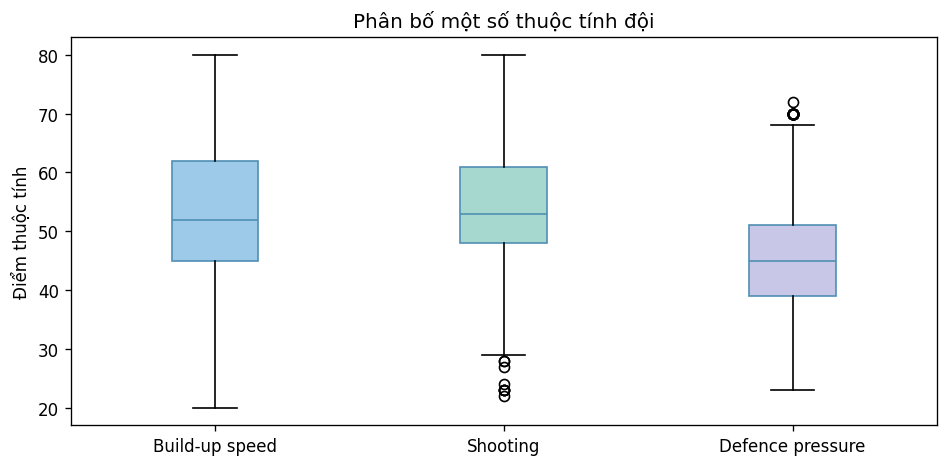

In [19]:
attribute_correlation = team_attributes[ATTRIBUTE_COLUMNS].corr().round(2)

print("Correlation matrix của các thuộc tính đội:")
display(attribute_correlation)

plot_team_attribute_distribution(
    team_attributes,
    columns=["buildUpPlaySpeed", "chanceCreationShooting", "defencePressure"],
    labels=["Build-up speed", "Shooting", "Defence pressure"],
)
plt.show()


**Nhận xét**

Các thuộc tính chiến thuật được chọn đều là numeric và không có missing; phần lớn giá trị nằm trong khoảng 20-80 tùy cột. Mỗi đội có từ 1 đến 6 bản ghi, median là 6, cho thấy đây là snapshot theo thời gian chứ không phải thuộc tính cố định của đội. Correlation matrix chỉ giúp nhận diện quan hệ tuyến tính ban đầu giữa các thuộc tính, chưa thể kết luận thuộc tính nào phản ánh thành tích thực tế nếu chưa liên kết đúng theo season.


## 5. EDA sơ bộ theo câu hỏi phân tích

Mục này kiểm tra pattern ban đầu và tính khả thi dữ liệu cho năm câu hỏi phân tích. Các bảng tổng hợp trong mục này chỉ là DataFrame tạm thời phục vụ EDA.


### 5.1. Coverage phục vụ Q1 – League competitiveness

Kiểm tra số trận, số đội theo league-season và các league-season có coverage bất thường.


In [20]:
league_season_teams = []
for (league_name, season), group in match_enriched.groupby(["league_name", "season"]):
    teams = pd.concat([group["home_team_api_id"], group["away_team_api_id"]], ignore_index=True).dropna()
    league_season_teams.append({"league_name": league_name, "season": season, "match_count": len(group), "team_count": teams.nunique()})
league_season_teams = pd.DataFrame(league_season_teams)
league_season_summary = league_season_teams.groupby("league_name", as_index=False).agg(
    season_count=("season", "nunique"), min_matches=("match_count", "min"), median_matches=("match_count", "median"), max_matches=("match_count", "max"), min_teams=("team_count", "min"), median_teams=("team_count", "median"), max_teams=("team_count", "max"),
).sort_values("league_name")
coverage_with_baseline = league_season_teams.merge(league_season_teams.groupby("league_name", as_index=False)["match_count"].median().rename(columns={"match_count": "league_median_matches"}), on="league_name", how="left")
coverage_with_baseline["match_count_vs_median_pct"] = (coverage_with_baseline["match_count"] / coverage_with_baseline["league_median_matches"] * 100).round(1)
coverage_alerts = coverage_with_baseline.loc[coverage_with_baseline["match_count_vs_median_pct"] < 90].sort_values(["match_count_vs_median_pct", "league_name", "season"])

print("Tóm tắt coverage theo league-season:")
display(league_season_summary)
print("\nLeague-season có số trận thấp hơn 90% median của chính league:")
display(coverage_alerts)


Tóm tắt coverage theo league-season:


,league_name,season_count,min_matches,median_matches,max_matches,min_teams,median_teams,max_teams
0,Belgium Jupiler League,8,12,240.0,306,4,16.0,18
1,England Premier League,8,380,380.0,380,20,20.0,20
2,France Ligue 1,8,380,380.0,380,20,20.0,20
3,Germany 1. Bundesliga,8,306,306.0,306,18,18.0,18
4,Italy Serie A,8,358,380.0,380,20,20.0,20
5,Netherlands Eredivisie,8,306,306.0,306,18,18.0,18
6,Poland Ekstraklasa,8,240,240.0,240,16,16.0,16
7,Portugal Liga ZON Sagres,8,240,240.0,306,16,16.0,18
8,Scotland Premier League,8,228,228.0,228,12,12.0,12
9,Spain LIGA BBVA,8,380,380.0,380,20,20.0,20



League-season có số trận thấp hơn 90% median của chính league:


,league_name,season,match_count,team_count,league_median_matches,match_count_vs_median_pct
5,Belgium Jupiler League,2013/2014,12,4,240.0,5.0
1,Belgium Jupiler League,2009/2010,210,15,240.0,87.5


**Nhận xét**

Coverage theo league-season nhìn chung đủ để phục vụ Q1, nhưng `Belgium Jupiler League` có hai mùa thấp hơn 90% median của chính league. Mùa `2013/2014` là anomaly nghiêm trọng nhất với 12 trận và 4 đội; mùa `2009/2010` cũng thấp hơn median nhưng mức chênh lệch nhỏ hơn. Notebook chỉ ghi nhận anomaly và chưa kết luận nguyên nhân.


### 5.2. Pattern bàn thắng phục vụ Q2

Khảo sát bàn thắng trung bình mỗi trận, bàn thắng đội nhà/đội khách, trung bình theo league và theo season.


In [21]:
goal_overall = pd.DataFrame([
    {"metric": "Bàn thắng trung bình đội nhà", "value": match_metrics["home_team_goal"].mean()},
    {"metric": "Bàn thắng trung bình đội khách", "value": match_metrics["away_team_goal"].mean()},
    {"metric": "Tổng bàn thắng trung bình mỗi trận", "value": match_metrics["total_goals"].mean()},
])
goals_by_league = match_metrics.groupby("league_name", as_index=False).agg(match_count=("id", "count"), avg_home_goals=("home_team_goal", "mean"), avg_away_goals=("away_team_goal", "mean"), avg_total_goals=("total_goals", "mean")).sort_values("avg_total_goals", ascending=False)

print("Bàn thắng trung bình toàn dataset:")
display(goal_overall.round(3))
print("\nBàn thắng trung bình theo league:")
display(goals_by_league.round(3))


Bàn thắng trung bình toàn dataset:


,metric,value
0,Bàn thắng trung bình đội nhà,1.545
1,Bàn thắng trung bình đội khách,1.161
2,Tổng bàn thắng trung bình mỗi trận,2.706



Bàn thắng trung bình theo league:


,league_name,match_count,avg_home_goals,avg_away_goals,avg_total_goals
5,Netherlands Eredivisie,2448,1.780,1.301,3.081
10,Switzerland Super League,1422,1.663,1.267,2.930
3,Germany 1. Bundesliga,2448,1.627,1.275,2.902
0,Belgium Jupiler League,1728,1.609,1.192,2.802
9,Spain LIGA BBVA,3040,1.631,1.136,2.767
1,England Premier League,3040,1.551,1.160,2.711
8,Scotland Premier League,1824,1.429,1.204,2.634
4,Italy Serie A,3017,1.501,1.116,2.617
7,Portugal Liga ZON Sagres,2052,1.408,1.126,2.535
2,France Ligue 1,3040,1.403,1.040,2.443


Bàn thắng trung bình theo season:


,season,match_count,avg_home_goals,avg_away_goals,avg_total_goals
0,2008/2009,3326,1.505,1.102,2.607
1,2009/2010,3230,1.541,1.131,2.672
2,2010/2011,3260,1.548,1.135,2.684
3,2011/2012,3220,1.573,1.144,2.716
4,2012/2013,3260,1.550,1.223,2.773
5,2013/2014,3032,1.579,1.188,2.767
6,2014/2015,3325,1.520,1.155,2.676
7,2015/2016,3326,1.544,1.211,2.755


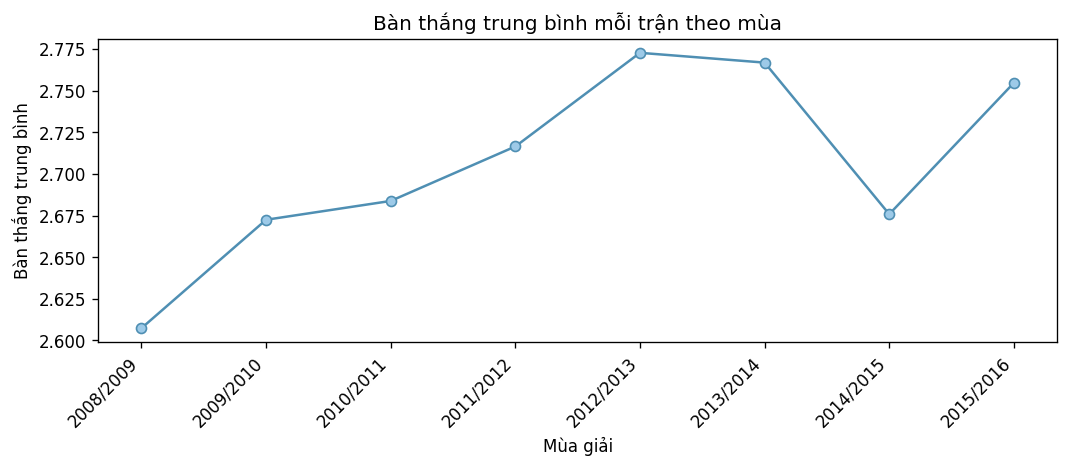

In [22]:
goals_by_season = match_metrics.groupby("season", as_index=False).agg(match_count=("id", "count"), avg_home_goals=("home_team_goal", "mean"), avg_away_goals=("away_team_goal", "mean"), avg_total_goals=("total_goals", "mean")).sort_values("season")

print("Bàn thắng trung bình theo season:")
display(goals_by_season.round(3))

plot_average_goals_by_season(goals_by_season)
plt.show()


**Nhận xét**

Bàn thắng trung bình có khác biệt đáng kể giữa các league: Netherlands Eredivisie cao nhất trong bảng tổng hợp với khoảng 3,08 bàn/trận, còn Poland Ekstraklasa thấp nhất với khoảng 2,43 bàn/trận. Theo mùa, tổng bàn thắng trung bình dao động trong khoảng 2,61-2,77 bàn/trận. Các pattern này hữu ích cho Q2, nhưng để đánh giá đội thành công dựa vào tấn công hay phòng ngự cần chuyển dữ liệu về cấp đội-mùa ở preprocessing.


### 5.3. Home advantage phục vụ Q3

Tạo biến kết quả tạm thời `Home Win`, `Draw`, `Away Win` và khảo sát tỷ lệ theo toàn dataset, league và season.


Tỷ lệ kết quả toàn dataset:


,result,rate_pct
0,Home Win,45.87
1,Draw,25.39
2,Away Win,28.74



Chênh lệch bàn thắng trung bình:


,metric,value
0,Chênh lệch bàn thắng sân nhà - sân khách,0.384


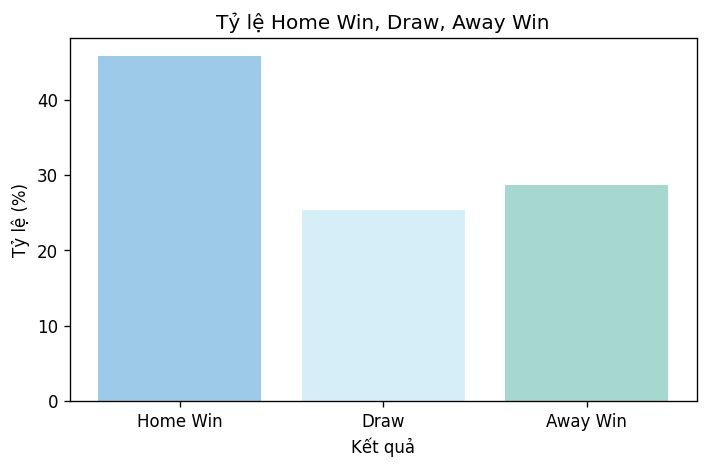

In [23]:
match_metrics["result"] = np.select(
    [
        match_metrics["home_team_goal"] > match_metrics["away_team_goal"],
        match_metrics["home_team_goal"] == match_metrics["away_team_goal"],
    ],
    ["Home Win", "Draw"],
    default="Away Win",
)
result_order = ["Home Win", "Draw", "Away Win"]
result_distribution = (
    match_metrics["result"]
    .value_counts(normalize=True)
    .reindex(result_order)
    .mul(100)
    .round(2)
    .rename_axis("result")
    .reset_index(name="rate_pct")
)
goal_diff_summary = pd.DataFrame([
    {"metric": "Chênh lệch bàn thắng sân nhà - sân khách", "value": match_metrics["goal_diff"].mean()}
])

print("Tỷ lệ kết quả toàn dataset:")
display(result_distribution)
print("\nChênh lệch bàn thắng trung bình:")
display(goal_diff_summary.round(3))

plot_match_result_distribution(result_distribution)
plt.show()


In [24]:
result_by_league = (
    pd.crosstab(match_metrics["league_name"], match_metrics["result"], normalize="index")
    .reindex(columns=result_order)
    .mul(100)
    .round(2)
    .reset_index()
)
result_by_season = (
    pd.crosstab(match_metrics["season"], match_metrics["result"], normalize="index")
    .reindex(columns=result_order)
    .mul(100)
    .round(2)
    .reset_index()
)

print("Tỷ lệ kết quả theo league:")
display(result_by_league)
print("\nTỷ lệ kết quả theo season:")
display(result_by_season)


Tỷ lệ kết quả theo league:


result,league_name,Home Win,Draw,Away Win
0,Belgium Jupiler League,46.88,24.59,28.53
1,England Premier League,45.72,25.76,28.52
2,France Ligue 1,44.70,28.26,27.04
3,Germany 1. Bundesliga,45.22,24.39,30.39
4,Italy Serie A,46.64,26.38,26.98
5,Netherlands Eredivisie,47.83,23.73,28.43
6,Poland Ekstraklasa,45.31,27.34,27.34
7,Portugal Liga ZON Sagres,44.25,25.97,29.78
8,Scotland Premier League,41.67,24.51,33.83
9,Spain LIGA BBVA,48.85,23.16,27.99



Tỷ lệ kết quả theo season:


result,season,Home Win,Draw,Away Win
0,2008/2009,47.08,24.98,27.93
1,2009/2010,47.43,25.20,27.37
2,2010/2011,46.63,25.74,27.64
3,2011/2012,46.52,25.40,28.07
4,2012/2013,44.29,26.17,29.54
5,2013/2014,46.31,24.27,29.42
6,2014/2015,44.93,25.56,29.50
7,2015/2016,43.87,25.71,30.43


**Nhận xét**

Toàn dataset có Home Win 45,87%, Draw 25,39% và Away Win 28,74%; chênh lệch bàn thắng trung bình sân nhà - sân khách là khoảng +0,384. Pattern này gợi ý lợi thế sân nhà tồn tại ở mức tổng quan và dữ liệu đủ để phân tích Q3 theo league hoặc season. Tuy nhiên, EDA chưa kiểm soát khác biệt về chất lượng đội, lịch thi đấu hoặc league format, nên chưa đưa ra kết luận cuối cùng về mức độ home advantage.


### 5.4. Team Attributes phục vụ Q4

Kiểm tra coverage của `Team_Attributes`, khả năng liên kết bằng `team_api_id`, range thuộc tính và vấn đề temporal alignment.


In [25]:
attribute_team_ids = set(team_attributes["team_api_id"].dropna())
match_team_ids = set(pd.concat([match["home_team_api_id"], match["away_team_api_id"]]).dropna())

attribute_coverage = pd.DataFrame([
    {"metric": "Số đội trong bảng Team", "value": len(team_ids)},
    {"metric": "Số đội xuất hiện trong Match", "value": len(match_team_ids)},
    {"metric": "Số đội có Team_Attributes", "value": len(attribute_team_ids)},
    {"metric": "Số đội trong Team không có Team_Attributes", "value": len(team_ids - attribute_team_ids)},
    {"metric": "Số đội trong Match không có Team_Attributes", "value": len(match_team_ids - attribute_team_ids)},
    {"metric": "Số team_api_id trong Team_Attributes không có trong Team", "value": len(attribute_team_ids - team_ids)},
])
attribute_date_range = pd.DataFrame([{"date_min": pd.to_datetime(team_attributes["date"], errors="coerce").min(), "date_max": pd.to_datetime(team_attributes["date"], errors="coerce").max(), "distinct_dates": team_attributes["date"].nunique()}])

print("Coverage của Team_Attributes:")
display(attribute_coverage)
print("\nKhoảng ngày thuộc tính:")
display(attribute_date_range)


Coverage của Team_Attributes:


,metric,value
0,Số đội trong bảng Team,299
1,Số đội xuất hiện trong Match,299
2,Số đội có Team_Attributes,288
3,Số đội trong Team không có Team_Attributes,11
4,Số đội trong Match không có Team_Attributes,11
5,Số team_api_id trong Team_Attributes không có ...,0



Khoảng ngày thuộc tính:


,date_min,date_max,distinct_dates
0,2010-02-22,2015-09-10,6


In [26]:
attribute_range = pd.DataFrame({"column_name": ATTRIBUTE_COLUMNS, "min": team_attributes[ATTRIBUTE_COLUMNS].min().values, "max": team_attributes[ATTRIBUTE_COLUMNS].max().values, "missing_rate_pct": (team_attributes[ATTRIBUTE_COLUMNS].isna().mean().values * 100).round(2)})
records_per_team_summary = team_attributes.groupby("team_api_id").size().describe().to_frame().T

print("Range và missing của thuộc tính:")
display(attribute_range)
print("\nSố lần ghi nhận thuộc tính trên mỗi đội:")
display(records_per_team_summary)


Range và missing của thuộc tính:


,column_name,min,max,missing_rate_pct
0,buildUpPlaySpeed,20,80,0.0
1,buildUpPlayPassing,20,80,0.0
2,chanceCreationPassing,21,80,0.0
3,chanceCreationCrossing,20,80,0.0
4,chanceCreationShooting,22,80,0.0
5,defencePressure,23,72,0.0
6,defenceAggression,24,72,0.0
7,defenceTeamWidth,29,73,0.0



Số lần ghi nhận thuộc tính trên mỗi đội:


,count,mean,std,min,25%,50%,75%,max
0,288.0,5.0625,1.540255,1.0,5.0,6.0,6.0,6.0


**Nhận xét**

`Team_Attributes` liên kết được với `Team` bằng `team_api_id` và không có identifier thuộc tính nằm ngoài bảng `Team`. Tuy nhiên chỉ 288/299 đội có thuộc tính, nghĩa là 11 đội từng thi đấu không có `Team_Attributes`; thêm vào đó bảng thuộc tính chỉ có 6 ngày snapshot trong giai đoạn 2010-2015. Q4 có thể thực hiện nhưng cần báo cáo coverage và thiết kế rule `temporal alignment` trước khi liên kết thuộc tính với thành tích.


### 5.5. Temporal feasibility phục vụ Q5

Kiểm tra số mùa mỗi đội xuất hiện, số đội xuất hiện nhiều mùa và xu hướng tổng quan qua mùa.


In [27]:
team_season_rows = []
for team_api_id in match_team_ids:
    team_matches = match.loc[(match["home_team_api_id"] == team_api_id) | (match["away_team_api_id"] == team_api_id)]
    team_season_rows.append({"team_api_id": team_api_id, "season_count": team_matches["season"].nunique(), "match_count": len(team_matches)})
team_temporal_coverage = pd.DataFrame(team_season_rows).merge(team, on="team_api_id", how="left")
team_temporal_summary = pd.DataFrame([
    {"metric": "Số đội chỉ xuất hiện trong một mùa", "value": int((team_temporal_coverage["season_count"] == 1).sum())},
    {"metric": "Số đội xuất hiện trong nhiều mùa", "value": int((team_temporal_coverage["season_count"] > 1).sum())},
    {"metric": "Median số mùa mỗi đội xuất hiện", "value": float(team_temporal_coverage["season_count"].median())},
    {"metric": "Số mùa tối đa mỗi đội xuất hiện", "value": int(team_temporal_coverage["season_count"].max())},
])

print("Tóm tắt coverage theo thời gian của đội:")
display(team_temporal_summary)
print("\nMột vài đội có ít mùa xuất hiện nhất:")
display(team_temporal_coverage.sort_values(["season_count", "match_count", "team_long_name"]).head(10))


Tóm tắt coverage theo thời gian của đội:


,metric,value
0,Số đội chỉ xuất hiện trong một mùa,52.0
1,Số đội xuất hiện trong nhiều mùa,247.0
2,Median số mùa mỗi đội xuất hiện,5.0
3,Số mùa tối đa mỗi đội xuất hiện,8.0



Một vài đội có ít mùa xuất hiện nhất:


,team_api_id,season_count,match_count,team_long_name,team_short_name
279,10213,1,30,Amadora,AMA
271,4064,1,30,Feirense,FEI
138,6351,1,30,KAS Eupen,EUP
26,9765,1,30,Portimonense,POR
139,177361,1,30,Termalica Bruk-Bet Nieciecza,TBN
186,7992,1,30,Trofense,TRO
127,9912,1,34,DSC Arminia Bielefeld,BIE
34,9776,1,34,Eintracht Braunschweig,BRA
278,6631,1,34,FC Dordrecht,DOR
137,8398,1,34,FC Energie Cottbus,COT


In [28]:
season_trend = match_metrics.groupby("season", as_index=False).agg(match_count=("id", "count"), avg_total_goals=("total_goals", "mean"), avg_goal_diff=("goal_diff", "mean")).sort_values("season")

print("Xu hướng tổng quan theo season:")
display(season_trend.round(3))


Xu hướng tổng quan theo season:


,season,match_count,avg_total_goals,avg_goal_diff
0,2008/2009,3326,2.607,0.403
1,2009/2010,3230,2.672,0.410
2,2010/2011,3260,2.684,0.413
3,2011/2012,3220,2.716,0.429
4,2012/2013,3260,2.773,0.327
5,2013/2014,3032,2.767,0.391
6,2014/2015,3325,2.676,0.365
7,2015/2016,3326,2.755,0.333


**Nhận xét**

Có 247 đội xuất hiện trong nhiều mùa và 52 đội chỉ xuất hiện trong một mùa; median số mùa mỗi đội xuất hiện là 5 và tối đa là 8. Điều này cho thấy Q5 khả thi với nhóm đội có lịch sử đủ dài, nhưng không nên so sánh trực tiếp đội chỉ có một mùa với đội có đủ toàn bộ giai đoạn. Nếu kết hợp với `Team_Attributes`, giới hạn 2010-2015 của bảng thuộc tính sẽ tiếp tục ảnh hưởng tới phân tích xu hướng.


## 6. Tổng hợp outlier và vấn đề cần lưu ý

Mục này gom các vấn đề EDA đáng chú ý thành bảng chuyển giao cho preprocessing. Các outlier chỉ được nhận diện bằng thống kê mô tả, quantile, IQR hoặc min/max; chưa xử lý hay gắn nhãn là lỗi.


In [29]:
_, total_goals_upper_fence = calculate_iqr_bounds(match_metrics["total_goals"])
total_goal_extreme_count = int((match_metrics["total_goals"] > total_goals_upper_fence).sum())

belgium_coverage_anomaly = coverage_alerts.loc[
    (coverage_alerts["league_name"] == "Belgium Jupiler League")
    & (coverage_alerts["season"] == "2013/2014")
].iloc[0]
team_attribute_duplicate_groups = int(
    team_attributes.groupby(["team_api_id", "date"]).size().gt(1).sum()
)
team_attribute_duplicate_rows = summarize_duplicate_key(
    team_attributes,
    ["team_api_id", "date"],
)["duplicate_rows"]

issue_summary = pd.DataFrame([
    {
        "table_name": "Team_Attributes",
        "column_name": "team_api_id + date",
        "issue_type": "Duplicate business key",
        "evidence": f"{team_attribute_duplicate_groups} nhóm duplicate, gồm {team_attribute_duplicate_rows} dòng",
        "potential_impact": "Có thể làm nhân dòng nếu join trực tiếp thuộc tính đội theo ngày",
        "recommended_next_step": "Xác định rule chọn snapshot hoặc xử lý duplicate trong preprocessing",
    },
    {
        "table_name": "Match",
        "column_name": "league_id + season",
        "issue_type": "Coverage anomaly",
        "evidence": f"Belgium Jupiler League 2013/2014 có {int(belgium_coverage_anomaly['match_count'])} trận và {int(belgium_coverage_anomaly['team_count'])} đội; median của league là {belgium_coverage_anomaly['league_median_matches']:.0f} trận",
        "potential_impact": "Có thể làm sai lệch chỉ số competitiveness nếu so sánh trực tiếp league-season",
        "recommended_next_step": "Điều tra và quyết định rule xử lý trước khi tính chỉ số cạnh tranh",
    },
    {
        "table_name": "Match",
        "column_name": "home_team_goal / away_team_goal / total_goals",
        "issue_type": "Extreme value",
        "evidence": f"Max home={match_metrics['home_team_goal'].max()}, max away={match_metrics['away_team_goal'].max()}, total_goals upper fence={total_goals_upper_fence:.2f}, extreme rows={total_goal_extreme_count}",
        "potential_impact": "Có thể ảnh hưởng mean và biểu đồ phân bố bàn thắng",
        "recommended_next_step": "Kiểm tra bằng domain knowledge, không loại tự động",
    },
    {
        "table_name": "Team_Attributes",
        "column_name": "team_api_id",
        "issue_type": "Coverage gap",
        "evidence": f"{len(match_team_ids - attribute_team_ids)} đội trong Match không có Team_Attributes",
        "potential_impact": "Q4 có thể mất một số đội khi liên kết thuộc tính với thành tích",
        "recommended_next_step": "Báo cáo coverage trước khi phân tích quan hệ thuộc tính - thành tích",
    },
    {
        "table_name": "Team_Attributes",
        "column_name": "date",
        "issue_type": "Temporal alignment issue",
        "evidence": f"Team_Attributes từ {team_attribute_dates.min().date()} đến {team_attribute_dates.max().date()}, Match từ {match_dates.min().date()} đến {match_dates.max().date()}",
        "potential_impact": "Không thể join trực tiếp thuộc tính vào trận/mùa nếu không có rule thời gian",
        "recommended_next_step": "Thiết kế rule mapping snapshot thuộc tính về season ở preprocessing",
    },
])
display(issue_summary)


,table_name,column_name,issue_type,evidence,potential_impact,recommended_next_step
0,Team_Attributes,team_api_id + date,Duplicate business key,"1 nhóm duplicate, gồm 2 dòng",Có thể làm nhân dòng nếu join trực tiếp thuộc ...,Xác định rule chọn snapshot hoặc xử lý duplica...
1,Match,league_id + season,Coverage anomaly,Belgium Jupiler League 2013/2014 có 12 trận và...,Có thể làm sai lệch chỉ số competitiveness nếu...,Điều tra và quyết định rule xử lý trước khi tí...
2,Match,home_team_goal / away_team_goal / total_goals,Extreme value,"Max home=10, max away=9, total_goals upper fen...",Có thể ảnh hưởng mean và biểu đồ phân bố bàn t...,"Kiểm tra bằng domain knowledge, không loại tự ..."
3,Team_Attributes,team_api_id,Coverage gap,11 đội trong Match không có Team_Attributes,Q4 có thể mất một số đội khi liên kết thuộc tí...,Báo cáo coverage trước khi phân tích quan hệ t...
4,Team_Attributes,date,Temporal alignment issue,"Team_Attributes từ 2010-02-22 đến 2015-09-10, ...",Không thể join trực tiếp thuộc tính vào trận/m...,Thiết kế rule mapping snapshot thuộc tính về s...


**Nhận xét**

`issue_summary` chỉ giữ các vấn đề có evidence thực sự khác 0 hoặc có anomaly rõ ràng. Các issue quan trọng gồm duplicate business key trong `Team_Attributes`, Belgium 2013/2014 có coverage bất thường, extreme values về bàn thắng, 11 đội thiếu `Team_Attributes`, và vấn đề `temporal alignment`. Các kiểm tra hợp lệ như coverage đầy đủ giữa `Team` và `Match` không còn được đưa vào danh sách vấn đề.


## 7. Kết luận và chuyển giao sang preprocessing

Tổng hợp ngắn gọn kết quả EDA và mức độ phù hợp của dữ liệu đối với năm câu hỏi phân tích. Phần này không đưa ra kết luận cuối cùng về đội mạnh, giải cạnh tranh nhất hay yếu tố quyết định chiến thắng.

**Kết luận**

Dataset đủ phù hợp để tiếp tục phân tích ở cấp trận đấu: `Match` bao phủ 2008-07-18 đến 2016-05-25, gồm 8 mùa, 11 quốc gia, 11 league và 299 đội; tất cả 299 đội trong `Team` đều xuất hiện trong `Match`. Các cột trận đấu quan trọng có coverage tốt, không có missing values, không có duplicate key và không phát hiện vi phạm `business rule` cơ bản.

Các vấn đề chính cần chuyển sang preprocessing gồm Belgium Jupiler League `2013/2014` có coverage anomaly nghiêm trọng, `Team_Attributes.team_api_id + date` có duplicate, 11 đội trong `Match` không có `Team_Attributes`, `Team_Attributes` chỉ bao phủ 2010-2015, và một số trận có extreme goal values theo IQR. Những điểm này cần rule rõ ràng trước khi tạo bảng phân tích.

Q1-Q3 có dữ liệu trực tiếp từ `Match` để tiếp tục phân tích sau khi tạo chỉ số phù hợp. Q4 và Q5 khả thi nhưng cần `temporal alignment` cho `Team_Attributes` và tiêu chí chọn đội đủ lịch sử; notebook này chỉ đánh giá tính khả thi, chưa trả lời câu hỏi kinh doanh cuối cùng.


In [30]:
connection.close()
print("SQLite connection closed.")


SQLite connection closed.
